# Trajectory analysis of myeloid cells in kidney allograft rejection

This Jupyter Notebook, provided as code supplement to our manuscript and shared on [GitHub](https://github.com/InsermRightLab/LILRB2-Varin-et-al), offers a complete step-by-step walkthrough of the computational workflow developped to determine the patterns at the single-cell resolution governing the differentiation of blood-circulating monocytes into tissue-infiltrating monocytes and finally macrophages, with an emphasis on elucidating the key features leading to the emergence of the pro-inflammatory macrophages secreting *CXCL10* identified as central in driving kidney allograft rejection.

The pipeline is run on a High Performance Computing (HPC) cluster using a Slurm scheduler on a node with 48 cores and 250GB of RAM. Maximum memory observed during the job was 186GB. We thank the Mésocentre de Franche-Comté for their facilities.

The complete document will be executed in one go using `Cell` => `Run All` and its total processing time will be monitored.

In [1]:
start.time <- Sys.time()
start.time

[1] "2025-04-17 17:40:31 CEST"

## Loading libraries and custom visualization functions

To clear up this notebook from large code blocks which might reduce its readability, all the custom code developped has been compiled into a package called [RightOmicsTools](https://alexis-varin.github.io/RightOmicsTools/) and into an R script included in the GitHub repository, which also contains the libraries loaded.

## Loading the Seurat object and colors

This work starts from a Seurat object corresponding to myeloid cells (Monocytes, Macrophages and cDC) which were subsetted from a larger Seurat object containing B, T and NK cells, endothelial cells and kidney structural cells as well, obtained from the merging of 33 biopsy scRNA-seq datasets and 13 blood scRNA-seq datasets in kidney allograft recipients undergoing rejection or not, integrated together in order to obtain a continuity from blood-circulating immune cells to tissue-infiltrating and tissue-resident immune cells. The myeloid cells, from both the blood and kidney compartments, were re-integrated and unsupervised clustering was re-applied in order to refine their cell types into 11 sub-clusters. We also provide two named vectors, corresponding to cell colors in our manuscript for their respective types and origin.

In [2]:
source("Utils_LILRB2_trajectory_analysis.R")

load("scRNA_biopsies&blood_rejection_myeloids_subset_seurat.RData")

myeloids.colors <- c("Classical-mo" = "lightblue",
                     "Mo-DC" = "#1FCC14",
                     "Non-classical-mo" = "blue",
                     "Intermediate-mo" = "#358FFF",
                     "IFN-activated-mo" = "#7ACC44",
                     "CXCL10+w" = "#CC1FBF",
                     "CD83+ mature DC" = "#008080",
                     "SELENOP+w" = "red",
                     "cDC2" = "cyan",
                     "cDC1" = "#11CED1",
                     "Patrolling-mo" = "#02193c")

tissues.colors <- c("Blood" = "firebrick4",
                    "Kidney allograft" = "lightgoldenrod4")

## Overview of the Seurat object

Below is a full description of the object.

In [3]:
myeloids.subset

An object of class Seurat 
40353 features across 37847 samples within 1 assay 
Active assay: RNA (40353 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 2 dimensional reductions calculated: pca, umap

Complete metadata of the samples.

In [4]:
metadata.df <- as.data.frame(do.call(rbind, strsplit(unique(paste(myeloids.subset@meta.data[["orig.ident"]],
                                                                  myeloids.subset@meta.data[["tissue"]],
                                                                  myeloids.subset@meta.data[["datasets"]],
                                                                  myeloids.subset@meta.data[["rejection_status"]],
                                                                  sep = "_")), "_")))

colnames(metadata.df) <- c("Sample", "Tissue", "Accession", "Publication", "Phenotype")

metadata.df

Sample,Tissue,Accession,Publication,Phenotype
<chr>,<chr>,<chr>,<chr>,<chr>
NAES01,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,Rejection
NAES02,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,No Rejection
NAES03,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,Rejection
NAES04,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,No Rejection
NAES05,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,Rejection
NAES06,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,Rejection
NAES07,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,No Rejection
NAES08,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,Rejection
NAES09,Blood,E-MTAB-11450,Van Loon et al. Kidney Int. 2022,No Rejection


Cell type proportions as a bar plot using our package RightOmicsTools.

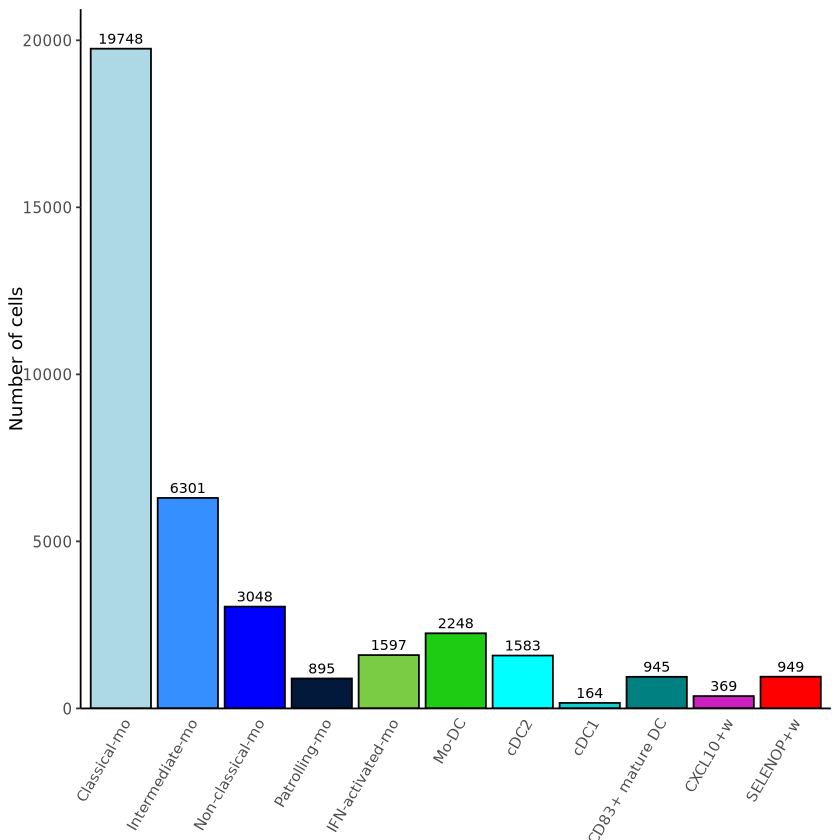

In [5]:
Idents(myeloids.subset) <- "named_clusters"

proportions.plot <- RightOmicsTools::Barplot_Cell_Proportion(myeloids.subset, colors = myeloids.colors)

proportions.plot

Cell type confirmation as a dot plot using our package RightOmicsTools and 1 marker for each type from our manuscript.

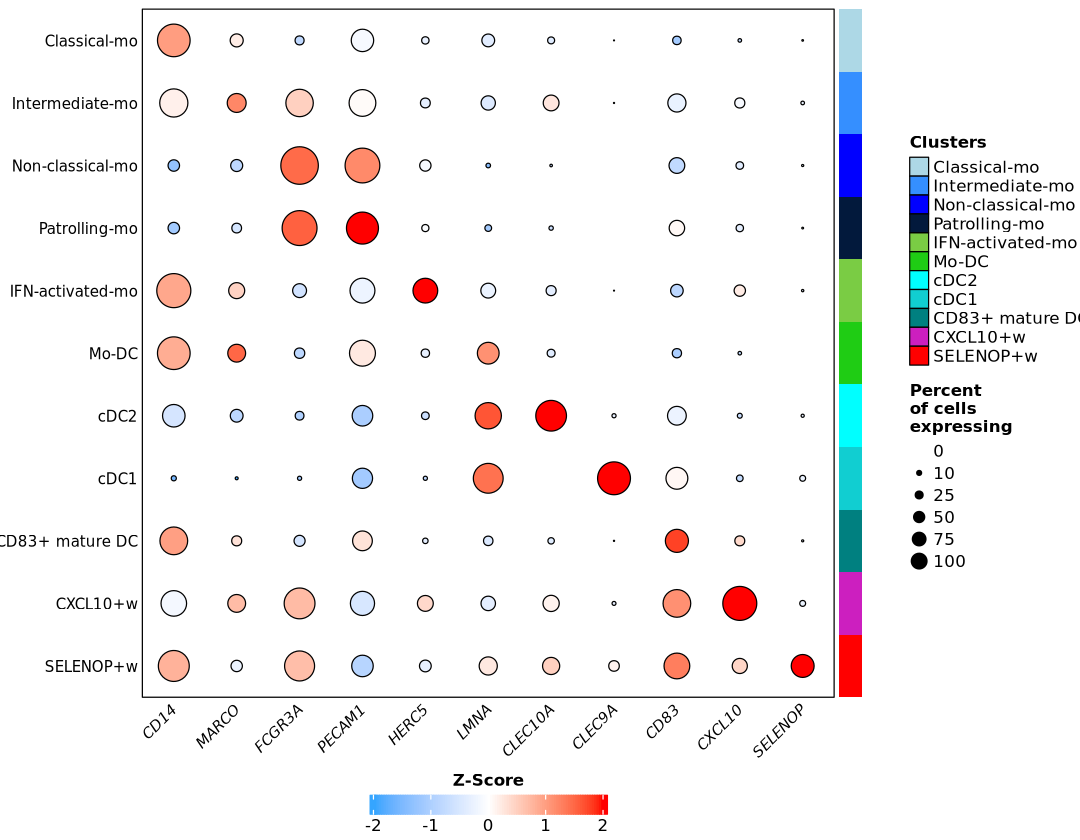

In [6]:
options(repr.plot.width=9) # only needed for plot size in Jupyter Notebook

markers.plot <- RightOmicsTools::DotPlot_Heatmap(myeloids.subset,
                                                 features = c("CD14", "MARCO", "FCGR3A", "PECAM1", "HERC5", "LMNA",
                                                              "CLEC10A", "CLEC9A", "CD83", "CXCL10", "SELENOP"),
                                                 cluster.idents = F,
                                                 cluster.features = F,
                                                 idents.colors = myeloids.colors)

markers.plot

The UMAP plot to conclude.

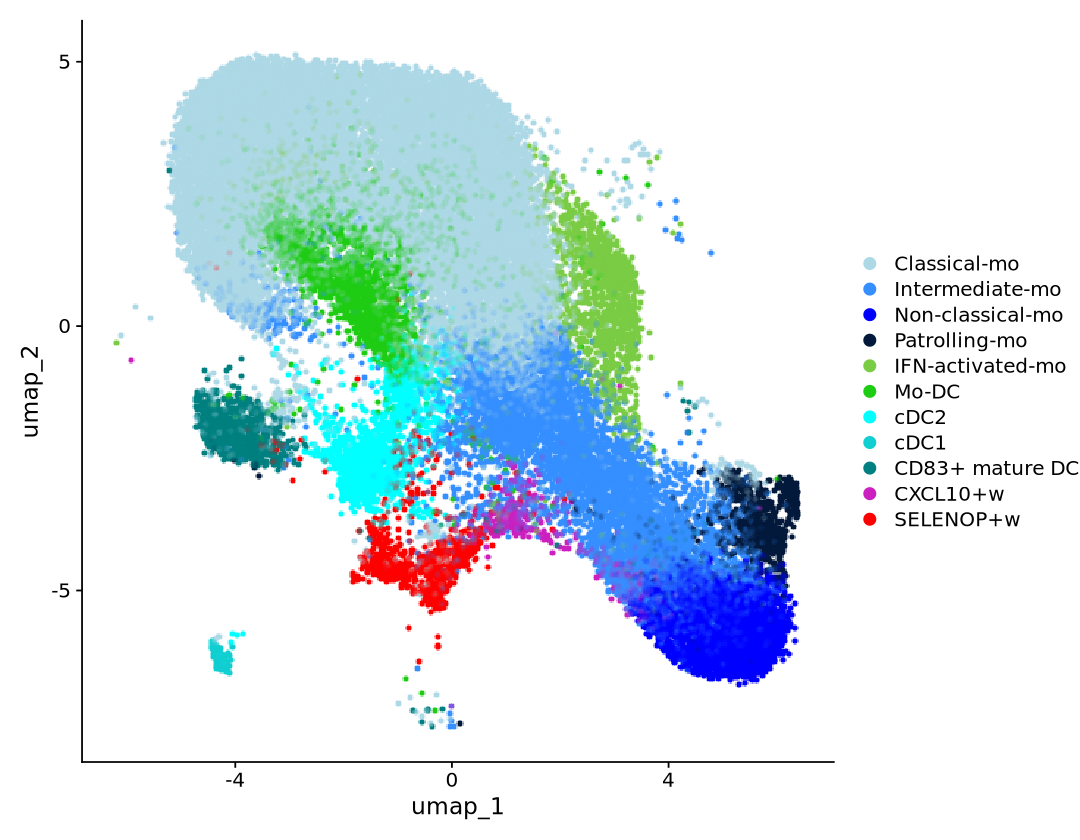

In [7]:
umap.plot <- DimPlot(myeloids.subset, pt.size = 2.5, raster = T, reduction = "umap", cols = myeloids.colors)

umap.plot

## Pseudotime inference

Trajectories will be determined using the package slingshot, which requires to convert the Seurat object into a SingleCellExperiment object, to infer the lineages in an unsupervised manner, only specifying that the trajectories should start from blood-derived classical monocytes.

In [8]:
sce <- as.SingleCellExperiment(myeloids.subset, assay = "RNA")

sds <- slingshot(sce, reducedDim = 'UMAP', clusterLabels = colData(sce)$named_clusters, start.clus = 'Classical-mo')

Overview of the SingleCellExperiment object created by slingshot.

In [9]:
sds

class: SingleCellExperiment 
dim: 40353 37847 
metadata(0):
assays(2): counts logcounts
rownames(40353): AL627309.1 AL669831.5 ... AC244102.3 PNMA6E
rowData names(0):
colnames(37847): AAACCTGAGCTGATAA-1_17 AAACCTGAGGTAGCTG-1_17 ...
  TGTGGTACAAGCGAGT-1_46 TTGACTTTCATCGGAT-1_46
colData names(22): orig.ident nCount_RNA ... slingPseudotime_6
  slingPseudotime_7
reducedDimNames(2): PCA UMAP
mainExpName: RNA
altExpNames(0):

We first explore the inference results using tradeSeq's native function, plotGeneCount (slingshot and tradeSeq functions work in tandem as they were designed to be used together and developped by the same team), which plots lineages on the UMAP coordinates.

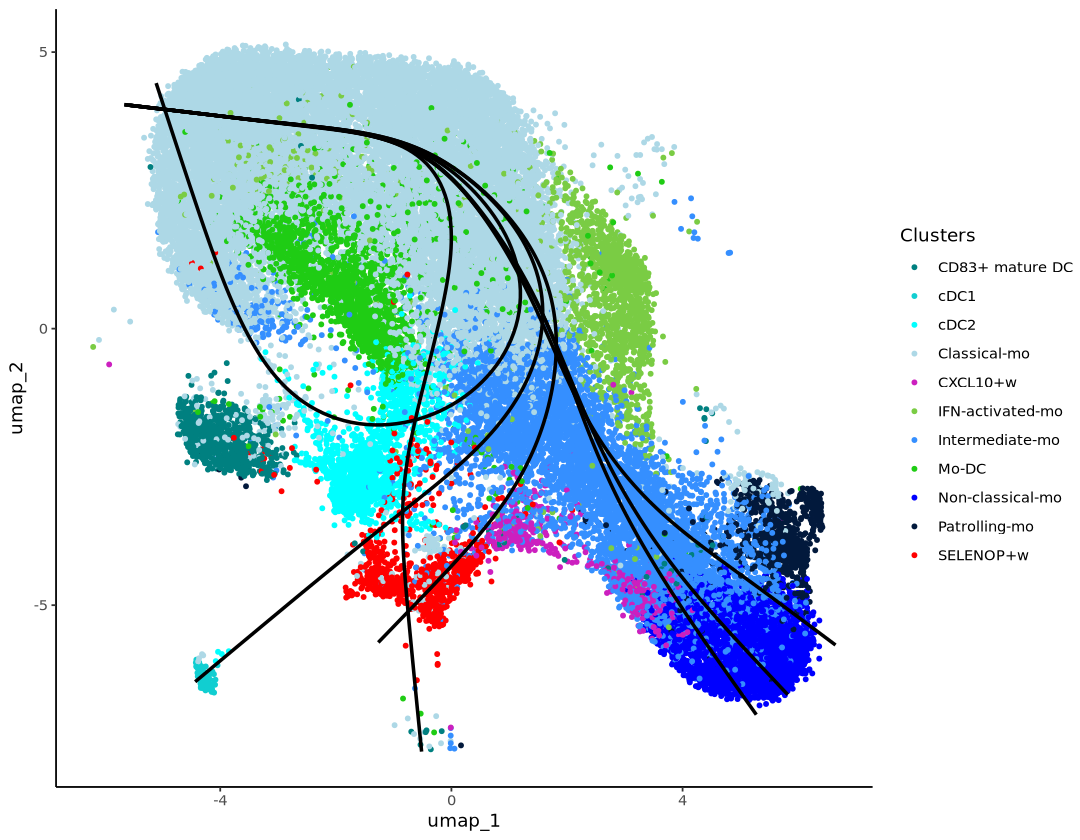

In [10]:
slingshot.plot <- plotGeneCount(sds, clusters = colData(sds)$named_clusters) +
                  labs(x = "umap_1", y = "umap_2") +
                  scale_color_manual(values = myeloids.colors)

slingshot.plot

Slingshot stores all results in an object within the SingleCellExperiment object. Interestingly, we can extract a lot of useful data from this object, including the ability to determine the cluster where slingshot predicts each lineage ends, to confirm the identity of each trajectory.

In [11]:
ending.clusters <- unlist(lapply(metadata(colData(sds)$slingshot)[["lineages"]], function(lin) lin[length(lin)]))
                              
ending.clusters

Lineage1           Lineage2           Lineage3           Lineage4 
 "CD83+ mature DC"        "SELENOP+w"             "cDC1" "Non-classical-mo" 
          Lineage5           Lineage6           Lineage7 
        "CXCL10+w"    "Patrolling-mo"            "Mo-DC"

Based on these results, we decided to exclude lineage 7, as it doesn't seem to be biologically relevant, especially considering it ends in a small group of mixed cells which do not seem to match the ending cluster (Mo-DC). We developped a custom ggplot2 code to be able to select and color the lineages based on their ending cluster as well as show the average pseudotime values on a continuous scale.

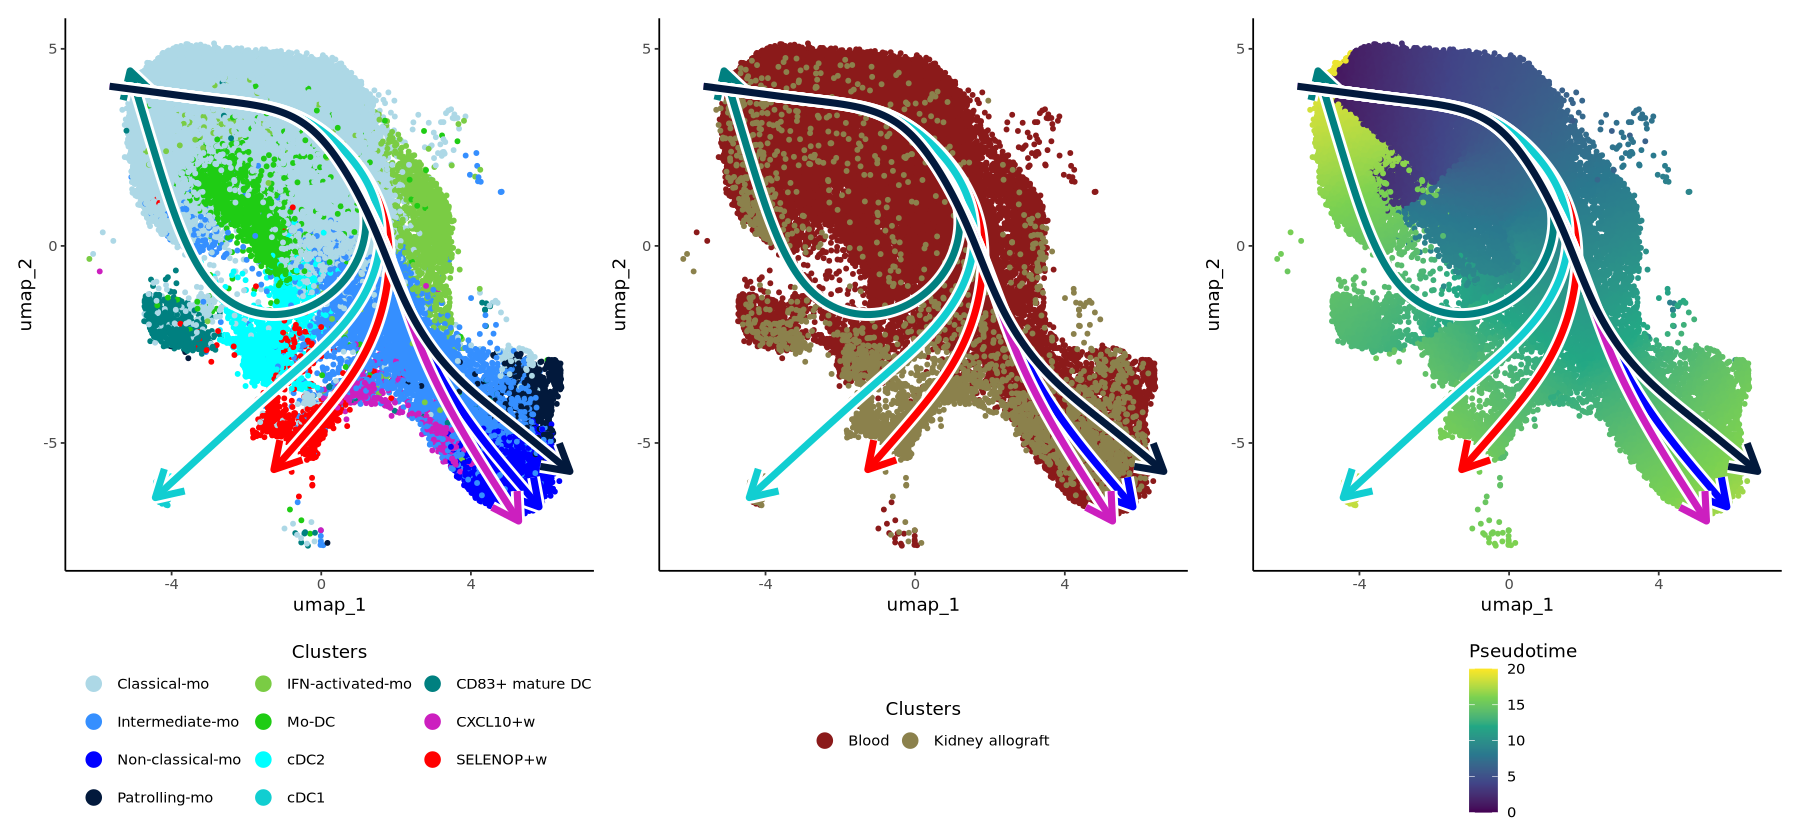

In [12]:
options(repr.plot.width=15) # only needed for plot size in Jupyter Notebook

curves.colors <- unname(myeloids.colors[ending.clusters])

lineages.plots <- list(clusters = Right_LineagePlot(sds,
                                                    lineages = 1:6,
                                                    clusters = "named_clusters",
                                                    clusters.colors = myeloids.colors,
                                                    lineages.colors = curves.colors),
                       tissues = Right_LineagePlot(sds,
                                                   lineages = 1:6,
                                                   clusters = "tissue",
                                                   clusters.colors = tissues.colors,
                                                   lineages.colors = curves.colors),
                       pseudotime = Right_LineagePlot(sds,
                                                      lineages = 1:6,
                                                      clusters = "pseudotime",
                                                      lineages.colors = curves.colors))

wrap_plots(lineages.plots)

## Pseudotime differential expression analysis

We will use the package tradeSeq to determine the key features governing fate choice and varying along pseudotime. The function `fitGAM()` fits a negative binomial generalized additive model (NB-GAM) for each gene on each trajectory, which is then used to select genes associated with lineages of interest (as computed by various statistical test functions also provided by tradeSeq). The drawback of this method is its computational burden, requiring an HPC cluster, which, even in this environment, may fail to often complete for larger objects due to hitting the wall-clock limit (maximum allowed time of a job on the cluster).

### Filtering

Through trials and errors, we found that removing lowly expressed genes is important to speed computation, as the time required to fit the model for a gene increases exponentially as fewer cells express it in various tests we carried out. We developped a custom function, included in our package RightOmicsTools, to remove all genes expressed by 10 cells or less in the object, as these represent likely noise or genes expressed in non-myeloid cells from the larger object such as kidney structural cells or T cells, as well as remove all mitochondrial, ribosomal and non-coding genes, since we would prefer to concentrate on protein-coding genes, before plotting an overview of the number of genes removed per number of cells expressing or condition.

Removed 22368 genes expressed in less than 11 cells, 17985 remaining (44.57%)

Removed 3895 non-coding genes, 14090 remaining (34.92%)

Removed 13 mitochondrial genes, 14077 remaining (34.88%)

Removed 96 ribosomal genes, 13981 remaining (34.65%)



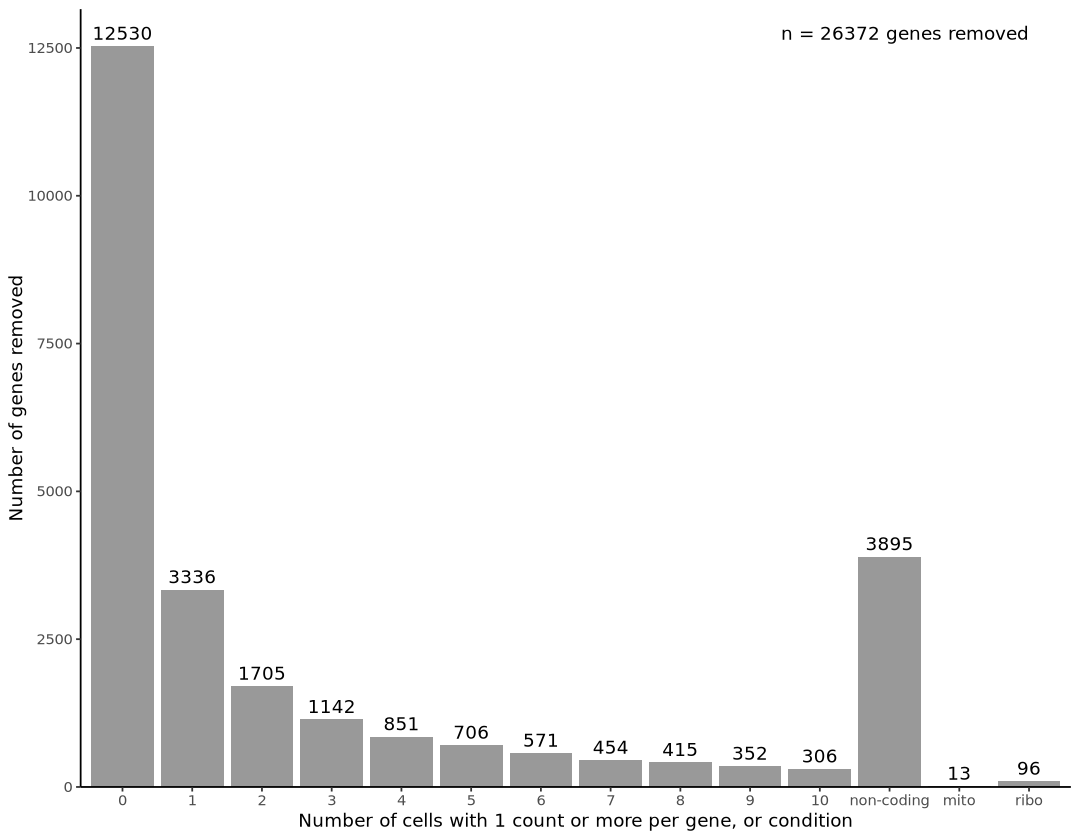

In [13]:
options(repr.plot.width=9) # only needed for plot size in Jupyter Notebook

sds.filtered <- RightOmicsTools::tradeSeqPreprocess(sds, min.cells = 11,
                                                    filter.mito = T,
                                                    filter.ribo = T,
                                                    filter.ncRNA = T)

Overview of the SingleCellExperiment object after filtering.

In [14]:
sds.filtered

class: SingleCellExperiment 
dim: 13981 37847 
metadata(0):
assays(2): counts logcounts
rownames(13981): NOC2L KLHL17 ... ATP5O C21orf33
rowData names(0):
colnames(37847): AAACCTGAGCTGATAA-1_17 AAACCTGAGGTAGCTG-1_17 ...
  TGTGGTACAAGCGAGT-1_46 TTGACTTTCATCGGAT-1_46
colData names(22): orig.ident nCount_RNA ... slingPseudotime_6
  slingPseudotime_7
reducedDimNames(2): PCA UMAP
mainExpName: RNA
altExpNames(0):

A total of 13981 genes were selected.

### Parallel computing

Model fitting can be further accelerated using BiocParallel, which tradeSeq has integrated. While this package provides classical functions to parallelize such as `MulticoreParam()` or `SnowParam()`, it also offers an additional option for HPC clusters based on another package called batchtools, which communicates directly with the scheduler to send computations as jobs on multiple nodes and cores, making it faster than classical parallelization options.

However, an error was encountered while using batchtools, which was caused by the class of the object (a dataframe) passed to `bplapply()` in the `.fitGAM()` function internally used to fit the models. While `MulticoreParam()` or `SnowParam()` are working well with the dataframe, `BatchtoolsParam()` stops from what seems to be an incorrect subset of the dataframe by `bplapply()`. We had to slightly modify the object to pass a list instead. The complete code is available in the R script included in the GitHub repository and can be compared to the native `.fitGAM()` function [here](https://github.com/statOmics/tradeSeq/blob/master/R/fitGAM.R). We opened an [issue](https://github.com/statOmics/tradeSeq/issues/261#issuecomment-2745381380) on tradeSeq's GitHub documenting this error and proposed the same fix described in this notebook. A small subset of 100 genes was used to compare model fitting between the native (dataframe) `fitGAM()` function with `MulticoreParam()` and our modified (list) `fitGAM()` function with `BatchtoolsParam()` to ensure rigorous reproductibility. All models were identical and our method, with the same number of cores, is approximately 9 times faster.

Since the node has 48 cores and this notebook uses 1, we will create 47 instances with 1 core and 4GB of memory each to parallelize the computations. Batchtools requires a template, a text file containing all the necessary bash scripts and commands to communicate with the scheduler, which has been included in the GitHub repository. Some parameters are specific to the HPC cluster used (such as partition name).

In [15]:
PARAM <- BatchtoolsParam(workers = 47,
                         cluster = "slurm",
                         resources = list(walltime = "24:00:00",
                                          partition = "bigmem",
                                          ncpus = 1,
                                          memory = "4G",
                                          job.name = "BPfitGAM"),
                         template = "slurm-mesoufc.tmpl")

### Determination of the number of knots

Before fitting the models, `fitGAM()` needs to be specified a parameter, called knots or k, which determines the number of points dividing each trajectory and explaining as much variability in the expression data as possible with only a few regression coefficients. For this purpose, we will use the tradeSeq's `evaluateK()` function, which will iteratively use `.fitGAM()` from a range of knot values, here 3 to 7, for a subset of 200 random genes, and outputs various statistical values evaluating the optimal k which has the lowest amount of genes underfitted or overfitted (either the model is missing important patterns or captures artifacts or noise in the data as patterns). Since the models are stochastic, we set a seed for reproducible results.

In [16]:
set.seed(1234)

evalK.time <- Sys.time()
aicMat <- evaluateK(counts = assays(sds.filtered)$counts,
                    sds = SlingshotDataSet(sds.filtered),
                    k = 3:7,
                    nGenes = 200,
                    plot = F,
                    parallel = T,
                    BPPARAM = PARAM)

Sys.time() - evalK.time

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.9 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.9 GiB”
Warning message in .findKnots(nknots, pseudotime, wSamp):
“Impossible to place a knot at all endpoints.Increase the number of knots to avoid this issue.”
Warning message in readLines(template):
“incomplete final line found on '/Work/Users/avarin/scRNA/LILRB2_trajectory_analysis/slurm-mesoufc.tmpl'”
Adding 200 jobs ...

Submitting 200 jobs in 47 chunks using cluster functions 'Slurm' ...

Clearing registry ...

Warning message in .findKnots(nknots, pseudotime, wSamp):
“Impossible to place a knot at all endpoints.Increase the number of knots to avoid this issue.”
Warning message in readLines(template):
“incomplete final line found on '/Work/Users/avarin/scRNA/LILRB2_trajectory_analysis/slurm-mesoufc.tmpl'”
Adding 200 jobs ...

Submitting 200 jobs in 47 chunks using cluster functions 'Slurm' ...

C

Time difference of 34.18312 mins

We will then visualize the data.

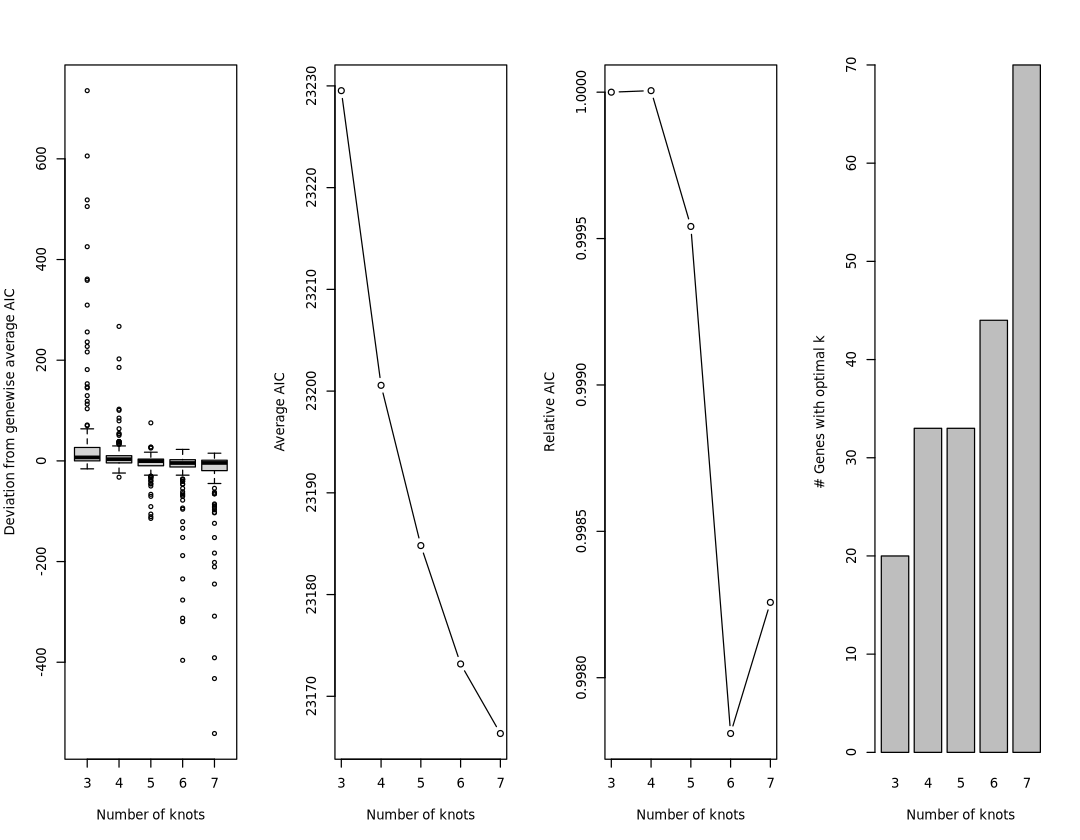

In [17]:
par(bg = "white") # only needed for plot background in Jupyter Notebook
evalK.plot <- plot_evalutateK_results(aicMat = aicMat)

Based on these values, we chose 5 knots to fit the models, considering it has the lowest deviation from genewise average AIC and therefore seems to have the lowest risk of underfitting or overfitting each given gene; a higher number of knots may seem better based on the number of genes with optimal k, but at the cost of overfitting quite a few genes considering the much higher negative deviation.

### Model fitting

We will now proceed with `fitGAM()`.

In [18]:
set.seed(1234)

fitGAM.time <- Sys.time()
GAM.results <- fitGAM(counts = assays(sds.filtered)$counts,
                      sds = SlingshotDataSet(sds.filtered),
                      nknots = 5,
                      parallel = T,
                      BPPARAM = PARAM)

Sys.time() - fitGAM.time

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.9 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.9 GiB”
Warning message in .findKnots(nknots, pseudotime, wSamp):
“Impossible to place a knot at all endpoints.Increase the number of knots to avoid this issue.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.9 GiB”
Warning message in readLines(template):
“incomplete final line found on '/Work/Users/avarin/scRNA/LILRB2_trajectory_analysis/slurm-mesoufc.tmpl'”
Adding 13981 jobs ...

Submitting 13981 jobs in 47 chunks using cluster functions 'Slurm' ...

Clearing registry ...



Time difference of 3.886524 hours

We first explore the results using tradeSeq's function plotGeneCount to visualize the knots on the lineages.

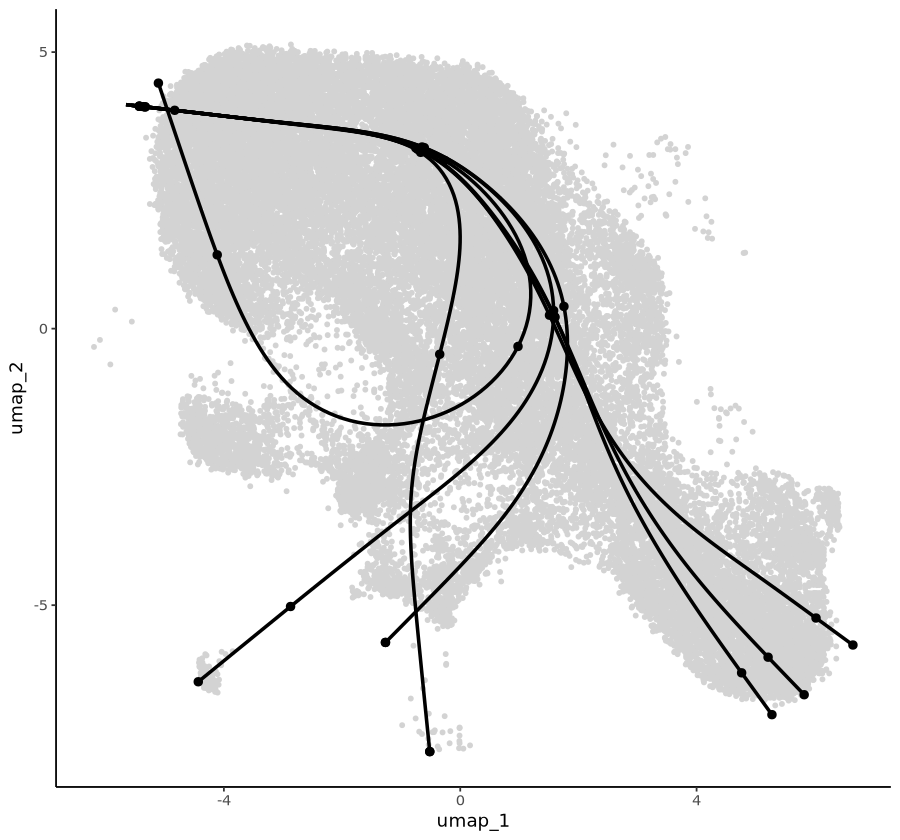

In [19]:
options(repr.plot.width=7.5) # only needed for plot size in Jupyter Notebook

fitGAM.plot <- plotGeneCount(sds.filtered, clusters = "none", models = GAM.results) +
               labs(x = "umap_1", y = "umap_2") +
               theme(legend.position = "none") +
               scale_color_manual(values = "lightgrey")

fitGAM.plot

We also included this option in our custom ggplot2 code to display these knots on the colored lineages.

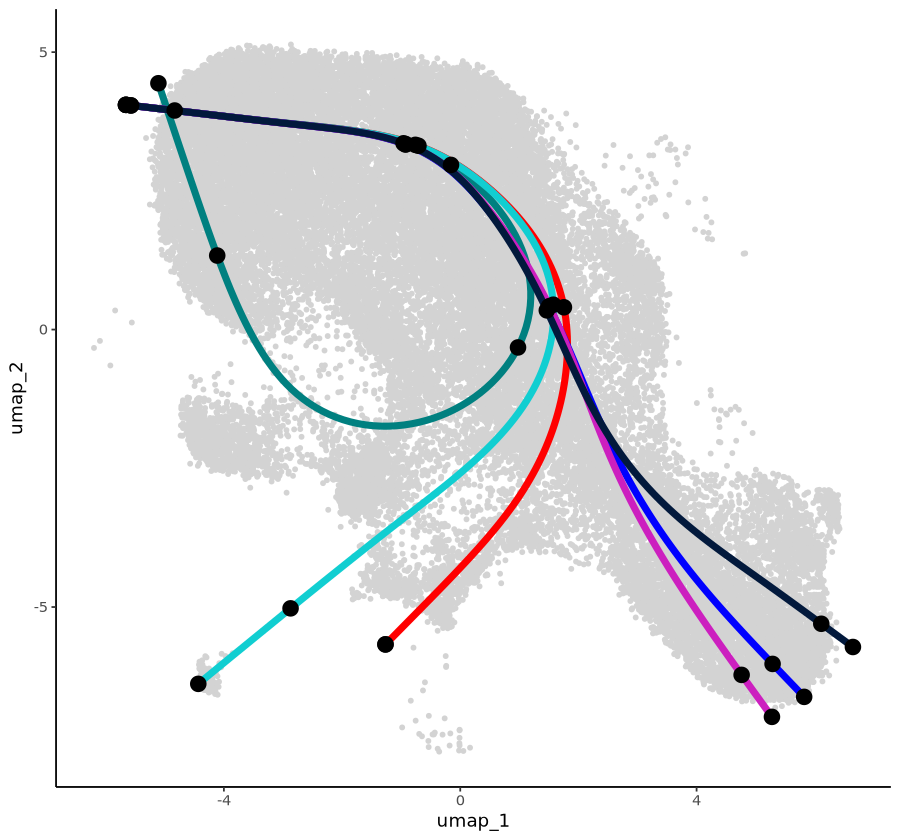

In [20]:
knots.plot <- Right_LineagePlot(sds.filtered,
                                models = GAM.results,
                                lineages = 1:6,
                                lineages.colors = curves.colors)

knots.plot

### Determination of genes associated with fate choice towards CXCL10+w

Knot 3 (near the center of the UMAP plot) seems to represent a branching point which could determine fate choice between the different ending clusters, as trajectories, which were overlapped, start to diverge past this knot. We will use one of tradeSeq's statistical tests, earlyDETest, which will perform a comparison of the model values for each gene between lineage pairs and knot 3 and 4 and returns a statistical value, called wald statistic, a p-value, correlated with the wald statistic, and a log fold change. We developped a custom code, included in our package RightOmicsTools, which is a wrapper around tradeSeq's statistical tests and computes on these test results an adjusted p-value based on false discovery rate (Benjamini & Hochberg) and arranges the lineage pairs into separate lists before ordering them based on decreasing waldStat values (most statistically significant genes first).

In [21]:
earlyDE.3vs4.results <- RightOmicsTools::tradeSeqTests(GAM.results, tests = "early", knots = c(3, 4))

str(earlyDE.3vs4.results)

Performing earlyDETest... 
Tidying data...
List of 1
 $ earlyDETest:List of 22
  ..$ Global     :'data.frame':	13981 obs. of  5 variables:
  .. ..$ waldStat   : num [1:13981] 12474 10910 9394 8458 7803 ...
  .. ..$ df         : num [1:13981] 16 17 17 16 17 17 16 17 16 16 ...
  .. ..$ pvalue     : num [1:13981] 0 0 0 0 0 0 0 0 0 0 ...
  .. ..$ padj       : num [1:13981] 0 0 0 0 0 0 0 0 0 0 ...
  .. ..$ medianLogFC: num [1:13981] 0.868 0.718 0.387 0.803 0.865 ...
  ..$ Lineage1vs2:'data.frame':	13981 obs. of  5 variables:
  .. ..$ waldStat   : num [1:13981] 4048 2706 2562 2366 2274 ...
  .. ..$ df         : num [1:13981] 4 4 4 4 4 4 4 4 4 4 ...
  .. ..$ pvalue     : num [1:13981] 0 0 0 0 0 0 0 0 0 0 ...
  .. ..$ padj       : num [1:13981] 0 0 0 0 0 0 0 0 0 0 ...
  .. ..$ medianLogFC: num [1:13981] 0.387 0.362 1.065 0.468 0.884 ...
  ..$ Lineage1vs3:'data.frame':	13981 obs. of  5 variables:
  .. ..$ waldStat   : num [1:13981] 6474 5011 4715 4608 4452 ...
  .. ..$ df         : num [1:13981

Since only the patterns relating to the CXCL10+w trajectory (therefore lineage 5) are of interest to us, we will subset the list accordingly.

In [22]:
earlyDE.3vs4.results.lin5 <- earlyDE.3vs4.results[[1]][grep("vs5|5vs6", names(earlyDE.3vs4.results[[1]]))]
names(earlyDE.3vs4.results.lin5)
names(earlyDE.3vs4.results.lin5) <- paste0(ending.clusters[5], " vs ", ending.clusters[c(1:4,6)])
names(earlyDE.3vs4.results.lin5)

[1] "Lineage1vs5" "Lineage2vs5" "Lineage3vs5" "Lineage4vs5" "Lineage5vs6"

[1] "CXCL10+w vs CD83+ mature DC"  "CXCL10+w vs SELENOP+w"       
[3] "CXCL10+w vs cDC1"             "CXCL10+w vs Non-classical-mo"
[5] "CXCL10+w vs Patrolling-mo"

We will remove all genes with an adjusted p-value above 0.05. We developped a custom ggplot2 code which builds a scatterplot based on the wald statistic and log fold change of each gene, and color them based on a rank score adapted from one of tradeSeq's [tutorial](https://www.bioconductor.org/packages/release/bioc/vignettes/tradeSeq/inst/doc/tradeSeq.html#example-on-combining-patterntest-with-diffendtest-results).

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


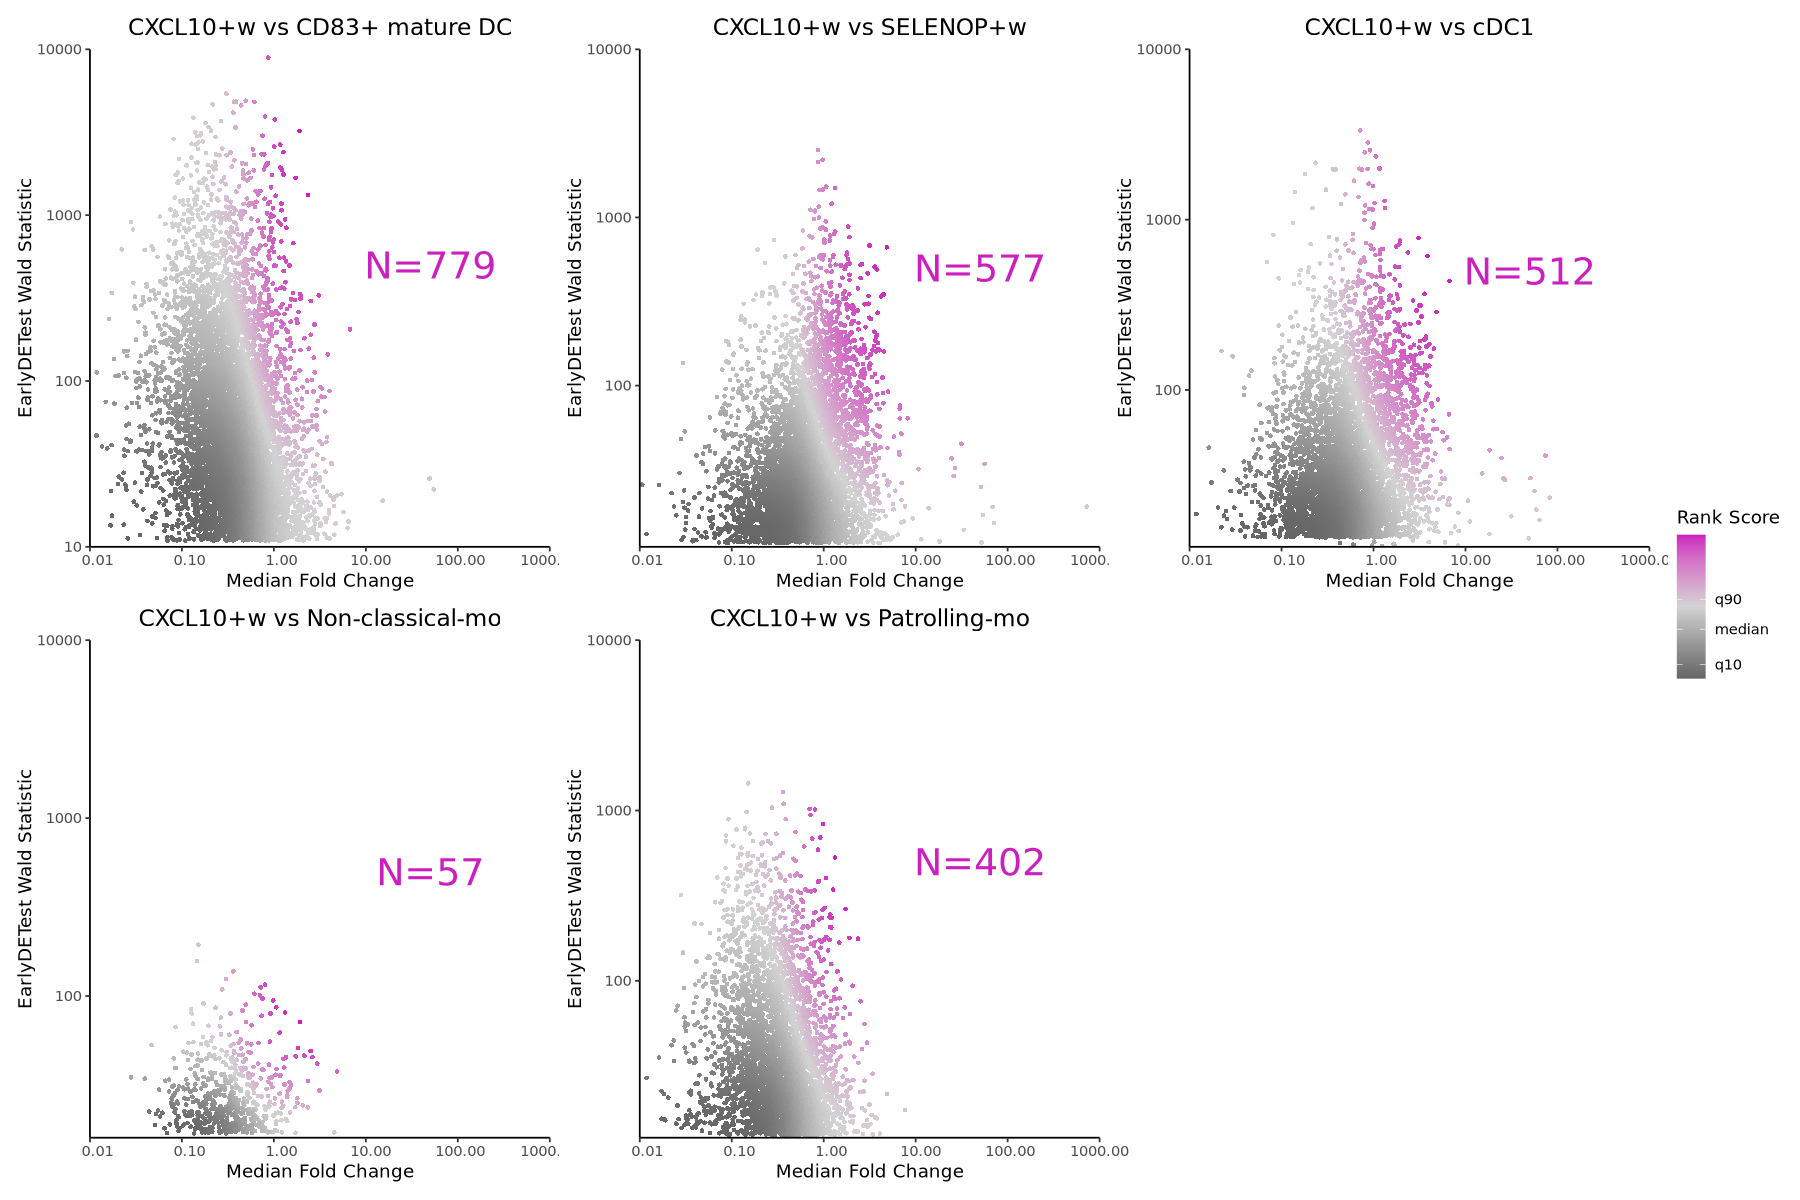

In [23]:
earlyDE.3vs4.results.lin5 <- lapply(earlyDE.3vs4.results.lin5, function(df) {
    df <- df[df[["padj"]] <= 0.05, , drop = F]
    df <- df[!is.na(df[["padj"]]), , drop = F]
    df$transientScore <- rank(df[["waldStat"]], ties.method = "random")^2 +
                         rank(df[["medianLogFC"]], ties.method = "random")^2      
    return(df)
})

options(repr.plot.width=15, repr.plot.height=10) # only needed for plot size in Jupyter Notebook

Wald.plots <- Right_WaldPlot(earlyDE.3vs4.results.lin5, score.color = myeloids.colors[ending.clusters[5]])
wrap_plots(Wald.plots, guides = "collect")

We will then use the data slot of each ggplot2 object to extract all genes with a transientScore value above quantile 0.90 (top 10% genes based on rank score) which represent the most differentially expressed genes between each pair of lineages.

In [24]:
earlyDE.3vs4.genes <- lapply(Wald.plots, function(plot) {
    rownames(plot[["data"]][plot[["data"]]$transientScore >= quantile(plot[["data"]]$transientScore, probs = 0.90), ])
})
names(earlyDE.3vs4.genes) <- ending.clusters[c(1:4,6)]
sapply(earlyDE.3vs4.genes, length)

CD83+ mature DC        SELENOP+w             cDC1 Non-classical-mo 
             779              577              512               57 
   Patrolling-mo 
             402

We will visualize the number of overlapping features using a Venn diagram and reorder the gene lists to display them as in our manuscript.

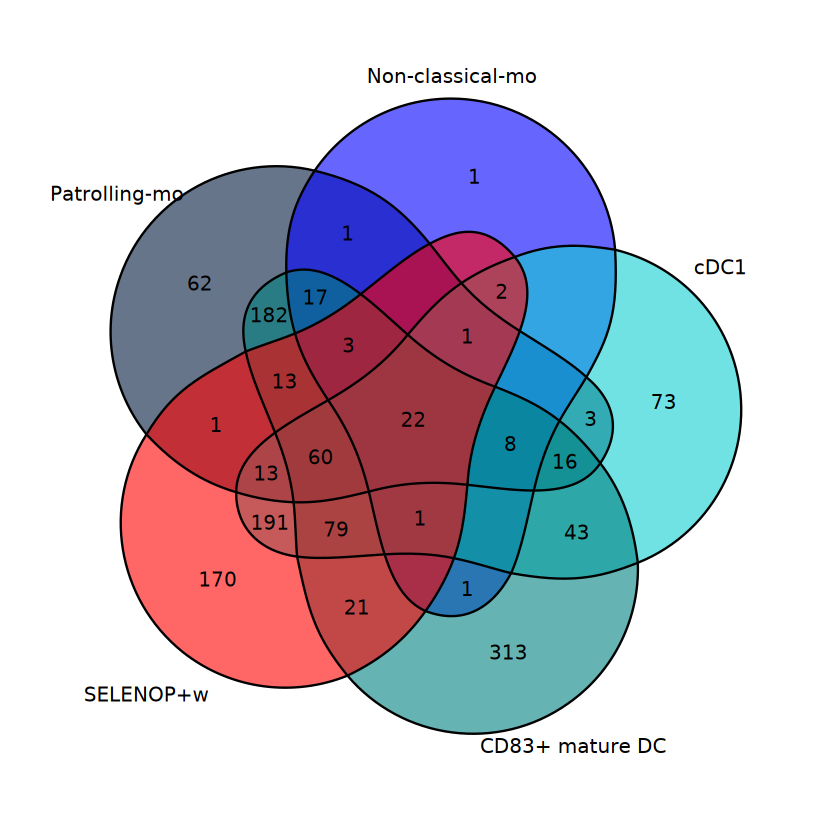

In [25]:
options(repr.plot.width=7, repr.plot.height=7) # only needed for plot size in Jupyter Notebook

earlyDE.3vs4.genes = rev(earlyDE.3vs4.genes[c(2,1,3:5)])

venn.plot <- venn(x = earlyDE.3vs4.genes,
                  zcolor = myeloids.colors[names(earlyDE.3vs4.genes)],
                  ilabels = "counts",
                  ggplot = T,
                  box = F,
                  ilcs = 1,
                  sncs = 1,
                  opacity = 0.6)

venn.plot

A total of 22 genes are found highly significant in all lineage comparison, and are the most likely gene candidates positively associated with the CXCL10+w trajectory. We will extract these genes by iteratively intersecting all gene lists with `Reduce()`.

In [26]:
most.DEG.lin5 <- Reduce(intersect, earlyDE.3vs4.genes)
print(most.DEG.lin5)

 [1] "LST1"     "LILRB2"   "LY6E"     "LILRA5"   "APOBEC3A" "LILRA2"  
 [7] "HLA-DPA1" "FCN1"     "C1QA"     "HLA-DRA"  "HLA-DQB1" "HLA-DPB1"
[13] "C1QB"     "CCL3"     "CCL3L1"   "CTSB"     "HLA-DQA1" "IFNGR1"  
[19] "CCL4"     "HLA-DMA"  "SLAMF8"   "CCL4L2"  


To represent these genes on the CXCL10+w trajectory, we developped a custom ComplexHeatmap code, included in our package RightOmicsTools, based on a [tutorial](https://hectorrdb.github.io/condimentsPaper/articles/KRAS.html#heatmaps-of-genes-de-between-conditions-for-lineage-1-1) for a package called condiments developped by the same team maintaining tradeSeq, which displays the smoothed (fitted) expression along pseudotime (therefore, from blood-derived classical monocytes to terminally differentiated macrophages), shows the cell densities and knots of the lineage at their precise pseudotime values, and uses k-means clustering to group genes of similar expression patterns together.

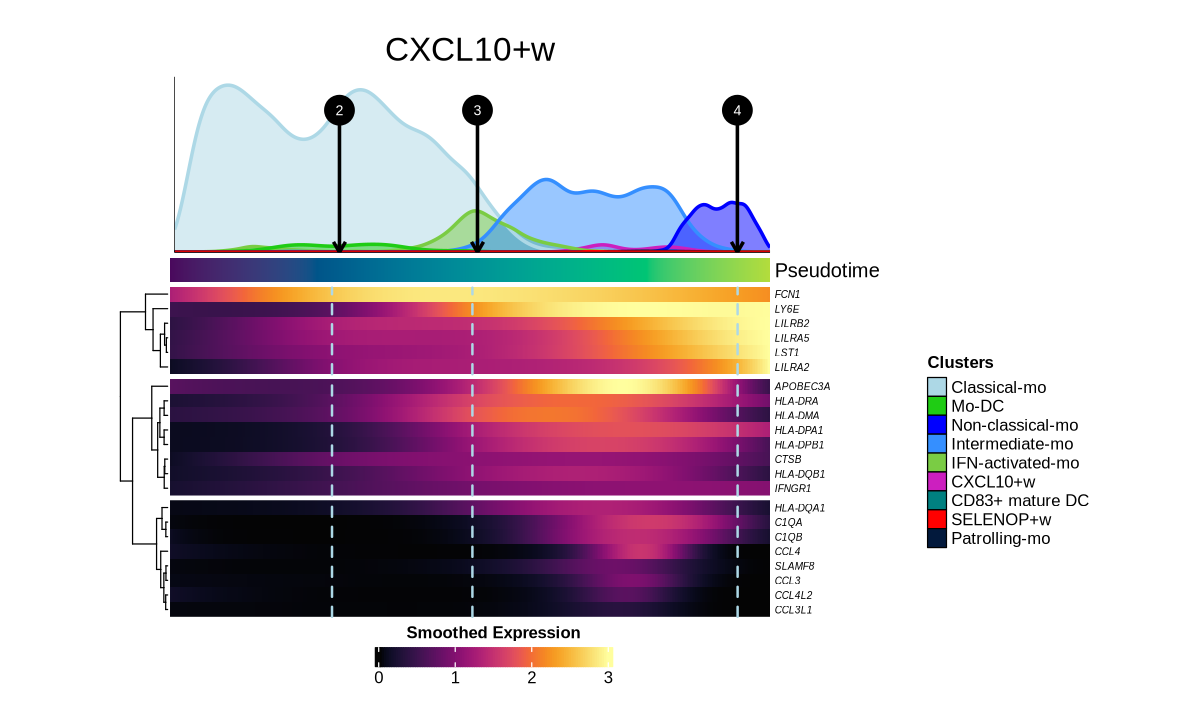

In [27]:
options(repr.plot.width=10, repr.plot.height=6) # only needed for plot size in Jupyter Notebook

heatmap.lin5 <- RightOmicsTools::heatmapSmoothers(sds.filtered, GAM.results, genes = most.DEG.lin5,
                                                  lineages = 5, lineages.to.remove = 7, 
                                                  clusters = "named_clusters", clusters.colors = myeloids.colors,
                                                  show.density.pseudotime.values = F, heatmap.names = ending.clusters[5],
                                                  density.height = 1.5, heatmap.width = 5, show_parent_dend_line = F,
                                                  branch.points = c("2" = "knot2","3" = "knot3","4" = "knot4"),
                                                  genes.kmeans = 3, genes.kmeans.numbers.size = 0, kmeans.repeats = 1000)

One of the clusters contains genes those expression increases towards the end of the trajectory: *LILRB2*, *LILRA5*, *LILRA2*, *FCN1*, *LST1* and *LY6E*.

To further examine these genes, we also designed a custom ggplot2 code, included in our package RightOmicsTools, based on tradeSeq's native function `plotSmoothers()`, to visualize the fitted expression along pseudotime of these genes as individual curves for each lineage and confirm they are most closely associated with the CXCL10+w trajectory, as well as represent the knots on the segments. Each rasterized point represent the log-normalized counts of each cell.

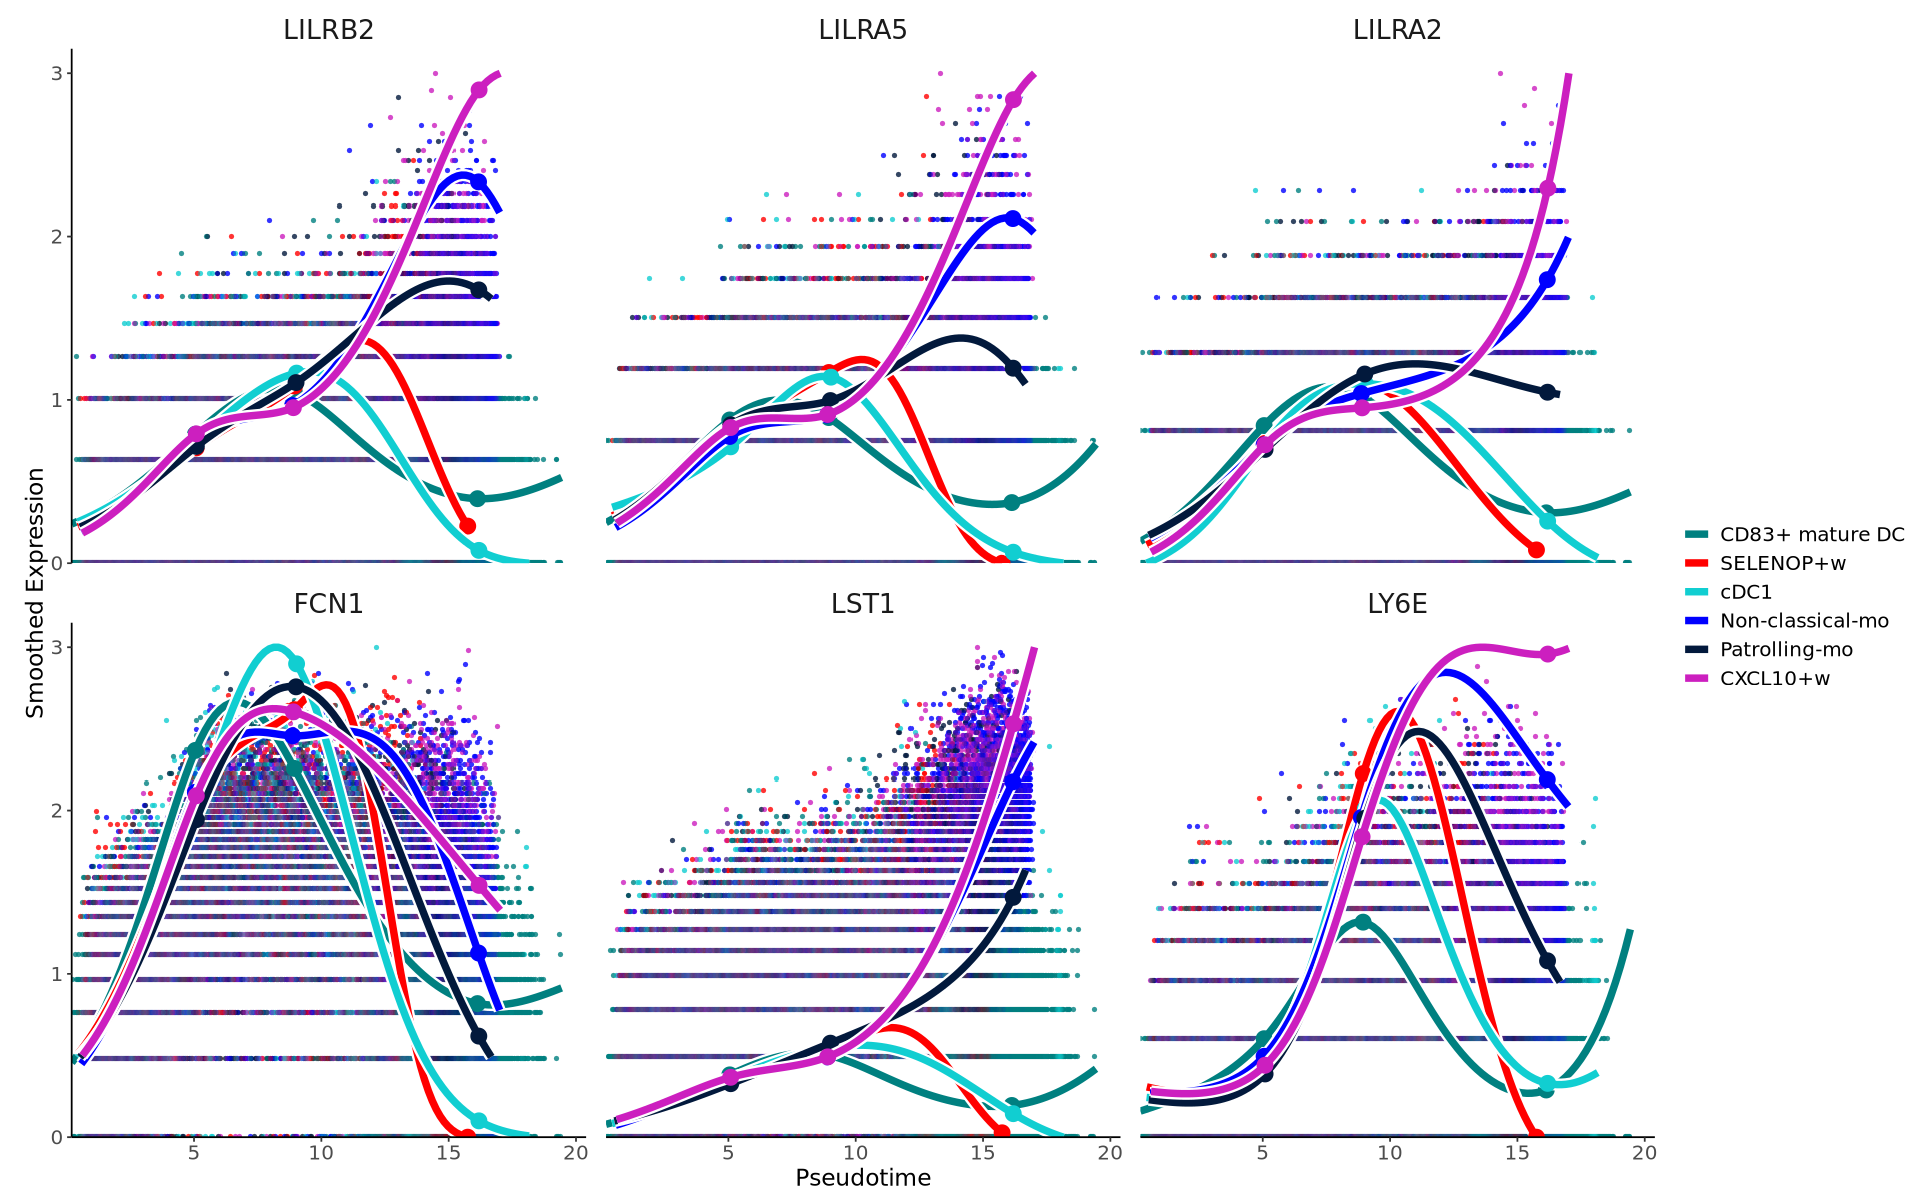

In [28]:
options(repr.plot.width=16, repr.plot.height=10) # only needed for plot size in Jupyter Notebook

curves.lin5 <- RightOmicsTools::curveSmoothers(GAM.results, genes = c("LILRB2","LILRA5","LILRA2","FCN1","LST1","LY6E"),
                                               lineages = c(1:4,6,5), lineages.to.remove = 7, curves.width = 2,
                                               legend.names = ending.clusters[c(1:4,6,5)],
                                               branch.points = c("2" = "knot2","3" = "knot3","4" = "knot4"),
                                               legend.text.size = 12, colors = curves.colors[c(1:4,6,5)],
                                               facets.title.size = 16, facets.axes = "margins",
                                               axis.title.size = 14, axis.text.size = 12)

curves.lin5

To conclude, we will use the same visualization function to explore the fitted expression in all other members of the LILR family.

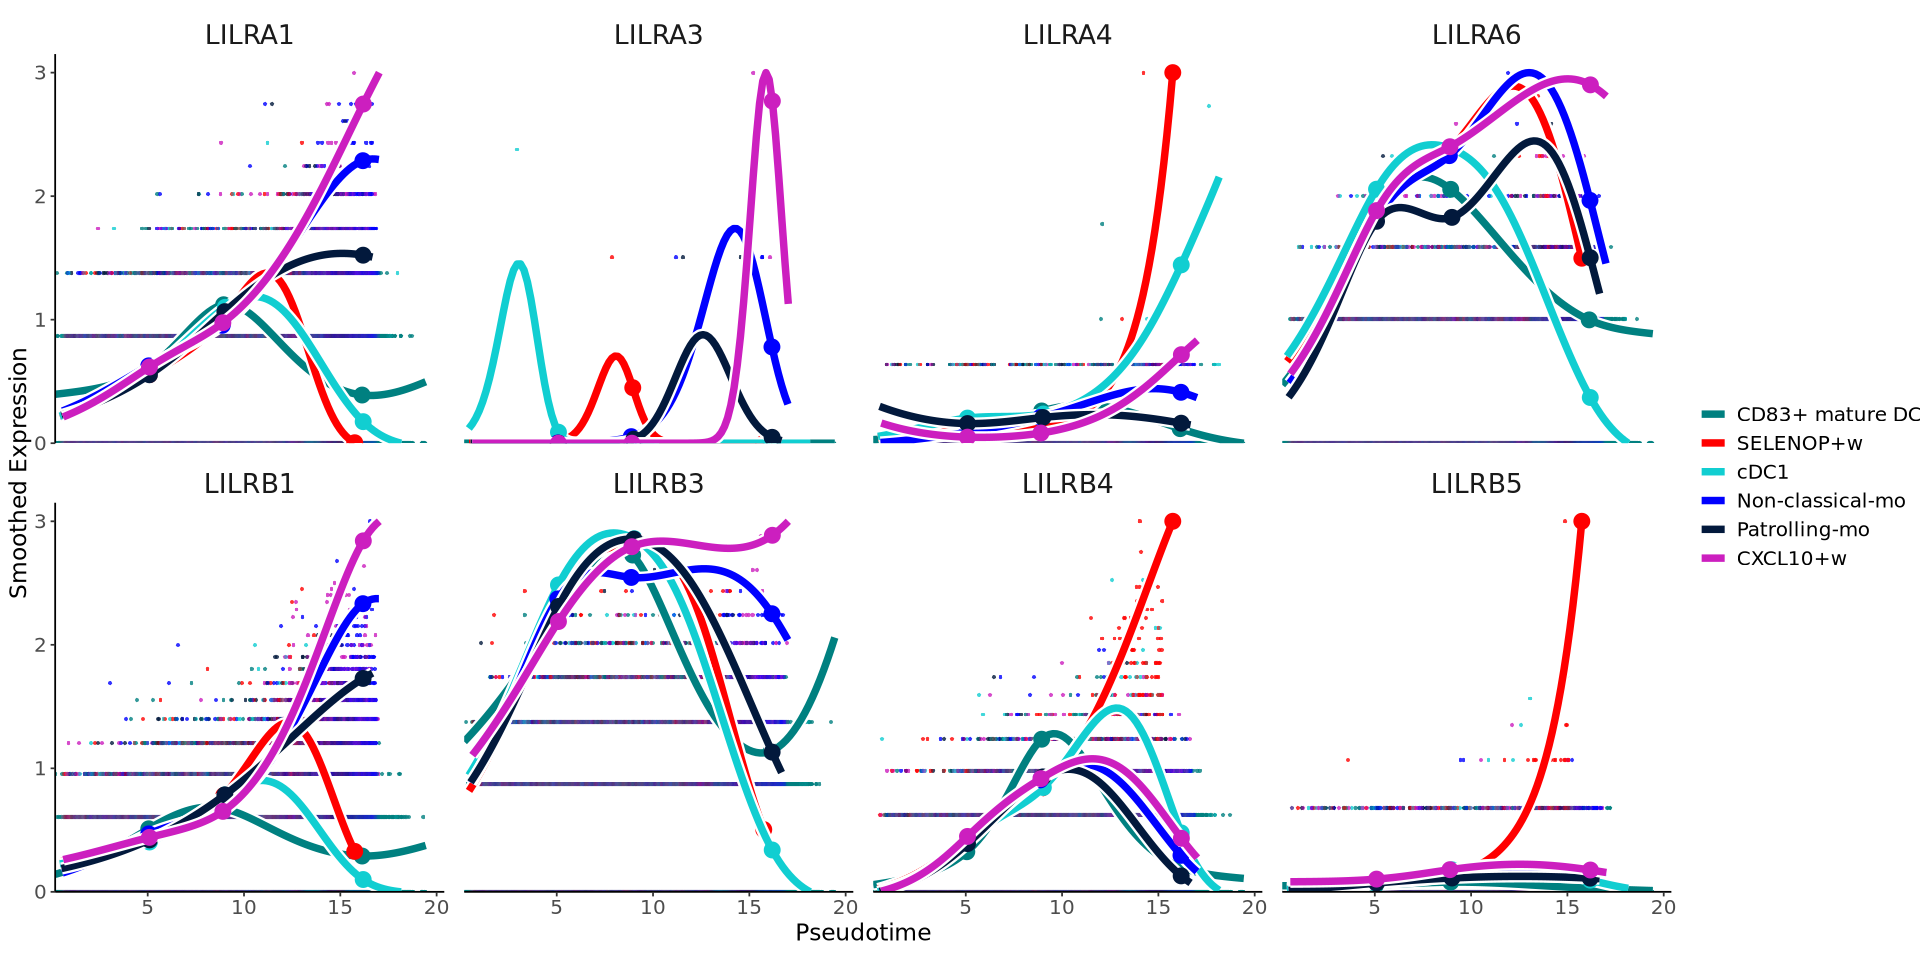

In [29]:
options(repr.plot.height=8) # only needed for plot size in Jupyter Notebook

curves.LILR <- RightOmicsTools::curveSmoothers(GAM.results, genes = c(paste0("LILRA", c(1,3,4,6)),
                                                                      paste0("LILRB", c(1,3:5))),
                                               lineages = c(1:4,6,5), lineages.to.remove = 7, curves.width = 2,
                                               legend.names = ending.clusters[c(1:4,6,5)],
                                               branch.points = c("2" = "knot2","3" = "knot3","4" = "knot4"),
                                               legend.text.size = 12, colors = curves.colors[c(1:4,6,5)],
                                               facets.title.size = 16, facets.axes = "margins",
                                               axis.title.size = 14, axis.text.size = 12, nrow = 2)

curves.LILR

We save all the results obtained in this notebook.

In [30]:
print(ls())
save(list = ls(), file = "Notebook_LILRB2_trajectory_analysis_results.RData")

 [1] "aicMat"                    "curves.colors"            
 [3] "curves.LILR"               "curves.lin5"              
 [5] "earlyDE.3vs4.genes"        "earlyDE.3vs4.results"     
 [7] "earlyDE.3vs4.results.lin5" "ending.clusters"          
 [9] "evalK.plot"                "evalK.time"               
[11] "evaluateK"                 "fitGAM"                   
[13] "fitGAM.plot"               "fitGAM.time"              
[15] "GAM.results"               "heatmap.lin5"             
[17] "knots.plot"                "lineages.plots"           
[19] "markers.plot"              "metadata.df"              
[21] "most.DEG.lin5"             "myeloids.colors"          
[23] "myeloids.subset"           "PARAM"                    
[25] "proportions.plot"          "Right_LineagePlot"        
[27] "Right_WaldPlot"            "sce"                      
[29] "sds"                       "sds.filtered"             
[31] "slingshot.plot"            "start.time"               
[33] "tissues.colors"   

File size of the saved results.

In [31]:
paste0(round(file.info("Notebook_LILRB2_trajectory_analysis_results.RData")$size/10^9, 3), "GB")

[1] "5.79GB"

Total processing time of this notebook.

In [32]:
Sys.time() - start.time

Time difference of 4.917644 hours

Overview of all the packages loaded and their version.

In [33]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 8.5 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /Work/Users/avarin/.conda/envs/scRNA_Renv/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Paris
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggplot2_3.5.1               RightOmicsTools_2.2.0      
 [3] BiocParallel_1.36.0         batchtools_0.9.17          
 [5] tradeSeq_1.16.0             slingshot_2.10.0           
 [7] Tra